# Parallel Trend Assumption
- 目的: 介入群と統制群において、指定期間内で平行トレンド仮定が満たされているかを確認する
- 方法: 1）傾きの検定方式 2）ベンチマーク方式（pseudo-ATT スードATT）の2パターン
- どちらの方法においても「帰無仮説が棄却できない場合に」PTAが満たされているとの解釈が成り立つ
- つまり、PTAが満たされていないとは言い難い、という弱い主張を検証していることに留意

In [1]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# from causalimpact import CausalImpact
# from prophet import Prophet
# import pymc as pm
# import arviz as az

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
print("pandas", pd.__version__)
print("numpy", np.__version__)
import matplotlib; print("matplotlib", matplotlib.__version__)
print("seaborn", sns.__version__)
# import causalimpact; print("causalimpact", causalimpact.__version__)
# import prophet; print("prophet", prophet.__version__)
# print("pymc", pm.__version__)
# print("arviz", az.__version__)

Created(JST) 2026-03-18 10:46:58
pandas 2.2.0
numpy 1.26.4
matplotlib 3.10.5
seaborn 0.13.2


In [2]:
# サンプルのdataframeを生成する

import string

# 乱数の固定
np.random.seed(42)

# --- 基本設定 ---
n_customers_per_store = 100  # 1店舗あたりの顧客数
days = 14  # 2週間分（前半7日が事前、後半7日が事後）
date_range = pd.date_range('2025-07-12', periods=days)
intervention_date = date_range[7]  # 7月19日から介入開始

stores = ['Store_A', 'Store_B']
menu = ['Coffee', 'Tea', 'Cake', 'Sandwich']
base_prices = {'Coffee': 450, 'Tea': 500, 'Cake': 800, 'Sandwich': 950}

# 1. 【マスター作成】店舗ごとの顧客属性
customer_data = []
for store in stores:
    chars = string.ascii_lowercase + string.digits
    ids = [''.join(np.random.choice(list(chars), 8)) for _ in range(n_customers_per_store)]
    for c_id in ids:
        customer_data.append({
            'customer_id': c_id,
            'store_id': store,
            'is_treatment': 1 if store == 'Store_A' else 0,
            'age': int(np.clip(np.random.normal(35, 10), 18, 70)),
            'gender': np.random.choice(['Male', 'Female', 'Other'])
        })

customer_master = pd.DataFrame(customer_data)

# 2. 【履歴作成】来店ログの生成
log_data = []
# 各顧客が各日に一定の確率で来店すると仮定
for _, row in customer_master.iterrows():
    for d in date_range:
        if np.random.rand() > 0.6:  # 来店確率40%
            item = np.random.choice(menu)
            price = base_prices[item] + np.random.normal(0, 50) # 基本価格 + ノイズ
            
            # --- 介入効果の付与 ---
            # Store A かつ 介入日以降の場合、価格を200円底上げする
            post_period = 1 if d >= intervention_date else 0
            treatment_effect = 0
            if row['is_treatment'] == 1 and post_period == 1:
                treatment_effect = 200
            
            price += treatment_effect
            
            log_data.append({
                'customer_id': row['customer_id'],
                'date': d,
                'menu': item,
                'price': round(price),
                # 'post_period': post_period  # 介入期間フラグ（必要に応じて）
            })

df_log = pd.DataFrame(log_data)

# 3. 【結合と整理】
df1 = pd.merge(df_log, customer_master, on='customer_id', how='left')
1
# DID用の交差項を作成
# df1['interaction'] = df1['is_treatment'] * df1['post_period']

# 曜日や月などの特徴量
df1['weekday'] = df1['date'].dt.strftime('%a')  # 日付から自動で曜日を生成
weekdays_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df1['weekday'] = pd.Categorical(df1['weekday'], categories=weekdays_order, ordered=True)
df1['menu'] = pd.Categorical(df1['menu'], categories=menu, ordered=True)

In [3]:
print(df1.head())
print(df1.tail())
# print(df1.info())

  customer_id       date      menu  price store_id  is_treatment  age  gender  \
0    2ohuswkk 2025-07-12  Sandwich   1000  Store_A             1   35  Female   
1    2ohuswkk 2025-07-13       Tea    462  Store_A             1   35  Female   
2    2ohuswkk 2025-07-14      Cake    814  Store_A             1   35  Female   
3    2ohuswkk 2025-07-15    Coffee    404  Store_A             1   35  Female   
4    2ohuswkk 2025-07-16      Cake    768  Store_A             1   35  Female   

  weekday  
0     Sat  
1     Sun  
2     Mon  
3     Tue  
4     Wed  
     customer_id       date      menu  price store_id  is_treatment  age  \
1082    z5969cih 2025-07-17      Cake    786  Store_B             0   18   
1083    z5969cih 2025-07-19  Sandwich    949  Store_B             0   18   
1084    z5969cih 2025-07-23  Sandwich    976  Store_B             0   18   
1085    z5969cih 2025-07-24      Cake    821  Store_B             0   18   
1086    z5969cih 2025-07-25       Tea    524  Store_B        

In [4]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   customer_id   1087 non-null   object        
 1   date          1087 non-null   datetime64[ns]
 2   menu          1087 non-null   category      
 3   price         1087 non-null   int64         
 4   store_id      1087 non-null   object        
 5   is_treatment  1087 non-null   int64         
 6   age           1087 non-null   int64         
 7   gender        1087 non-null   object        
 8   weekday       1087 non-null   category      
dtypes: category(2), datetime64[ns](1), int64(3), object(3)
memory usage: 62.2+ KB
None


# data check

In [5]:
# 列ごとに欠損値がいくつあるか
print(df1.isnull().sum())

# 欠損値の割合で見たい場合
print(df1.isnull().mean() * 100)

customer_id     0
date            0
menu            0
price           0
store_id        0
is_treatment    0
age             0
gender          0
weekday         0
dtype: int64
customer_id     0.0
date            0.0
menu            0.0
price           0.0
store_id        0.0
is_treatment    0.0
age             0.0
gender          0.0
weekday         0.0
dtype: float64


In [6]:
# 数値データのみを対象にする
print(df1.describe())

                                date        price  is_treatment          age
count                           1087  1087.000000   1087.000000  1087.000000
mean   2025-07-18 12:20:32.014719488   721.229071      0.506900    34.278749
min              2025-07-12 00:00:00   305.000000      0.000000    18.000000
25%              2025-07-15 00:00:00   492.500000      0.000000    27.000000
50%              2025-07-18 00:00:00   740.000000      1.000000    34.000000
75%              2025-07-22 00:00:00   920.000000      1.000000    40.000000
max              2025-07-25 00:00:00  1286.000000      1.000000    60.000000
std                              NaN   232.822303      0.500183     9.887886


In [7]:
# 「数値以外（カテゴリデータなど）」の要約（頻度やユニーク数）も見たい場合
df1.describe(exclude='number')

,customer_id,date,menu,store_id,gender,weekday
count,1087,1087,1087,1087,1087,1087
unique,200,NaN,4,2,3,7
top,4pnez1bf,NaN,Tea,Store_A,Male,Fri
freq,12,NaN,286,551,421,180
mean,NaN,2025-07-18 12:20:32.014719488,NaN,NaN,NaN,NaN
min,NaN,2025-07-12 00:00:00,NaN,NaN,NaN,NaN
25%,NaN,2025-07-15 00:00:00,NaN,NaN,NaN,NaN
50%,NaN,2025-07-18 00:00:00,NaN,NaN,NaN,NaN
75%,NaN,2025-07-22 00:00:00,NaN,NaN,NaN,NaN
max,NaN,2025-07-25 00:00:00,NaN,NaN,NaN,NaN


In [8]:
# 特定の列（例：menu）のユニークな値
print(df1['menu'].unique())

# それぞれの出現回数（多い順に）
print(df1['menu'].value_counts())

['Sandwich', 'Tea', 'Cake', 'Coffee']
Categories (4, object): ['Coffee' < 'Tea' < 'Cake' < 'Sandwich']
menu
Tea         286
Cake        284
Sandwich    260
Coffee      257
Name: count, dtype: int64


In [9]:
# 特定の列のユニークな値
print(df1['gender'].unique())

# それぞれの出現回数（多い順に）
print(df1['gender'].value_counts())

['Female' 'Male' 'Other']
gender
Male      421
Other     347
Female    319
Name: count, dtype: int64


In [10]:
# 特定の列のユニークな値の数
print(df1['customer_id'].nunique())

# それぞれの出現回数（多い順に）
print(df1['customer_id'].value_counts())

200
customer_id
4pnez1bf    12
vzcnkrlw    11
73mmr558    10
xzy2oayg    10
x9xcvbx3    10
            ..
qlvqjavz     2
vbzo7kcf     2
ifi45lhh     2
wskaxgyu     2
22pj3yte     2
Name: count, Length: 200, dtype: int64


In [11]:
df1.groupby(['is_treatment', 'store_id'])['price'].describe().sort_index(level=['is_treatment', 'store_id'], ascending=[False, True]).round(1)

,,count,mean,std,min,25%,50%,75%,max
is_treatment,store_id,,,,,,,,
1,Store_A,551.0,763.3,241.9,305.0,537.5,747.0,978.5,1286.0
0,Store_B,536.0,678.0,214.8,325.0,469.8,717.0,878.2,1058.0


## pre process for PTA check

In [12]:
# 介入日
base_date = df1["date"].min() + pd.Timedelta(days=7)
base_date

Timestamp('2025-07-19 00:00:00')

In [ ]:
# 時点カラムを整数値で表現したカラムを2種用意する（後で使う）
# データセット抽出時に準備済の場合はこの工程不要
# 1つめデータセット内の最古時点を1始まりとした（絶対的な）数値カラムを新設
# df1['absolute_ds'] = df1['date'].rank(method='dense').astype(int)  # 途中欠損日があるとそこ無視した連続数値になる
df1['absolute_ds'] = (df1['date'] - df1['date'].min()).dt.days + 1  # 途中欠損日があってもなんなく連続数値になる

# 2つめ介入開始時点の1時点前を基準とした（相対的な）数値カラムを新設
# 時点がすべて連続しているデータセットの場合は、基準時点からの相対的な時点番号を取得ですむが（日次での例）
# baseline_point = pd. Timestamp(' 2024-04-21°)
df1['relative_ds'] = (df1['date'] - base_date).dt.days + 1

# 連続していない場合（control/testと同じdateで2レコードあるなど）absolute_dsから加工する
# df1['relative_ds'] = df1['absolute_ds'] - 7  # before期間が7日間で基準点が7とわかってるのでその分だけ引く

In [14]:
df1.head()

,customer_id,date,menu,price,store_id,is_treatment,age,gender,weekday,absolute_ds,relative_ds
0,2ohuswkk,2025-07-12,Sandwich,1000,Store_A,1,35,Female,Sat,1,-6
1,2ohuswkk,2025-07-13,Tea,462,Store_A,1,35,Female,Sun,2,-5
2,2ohuswkk,2025-07-14,Cake,814,Store_A,1,35,Female,Mon,3,-4
3,2ohuswkk,2025-07-15,Coffee,404,Store_A,1,35,Female,Tue,4,-3
4,2ohuswkk,2025-07-16,Cake,768,Store_A,1,35,Female,Wed,5,-2


In [15]:
# 意図した通りにナンバリングできてるかcheck
# pd.pivot_table(df1, index=['date', 'absolute_ds', 'relative_ds'], values='customer_id', aggfunc='count')
pd.pivot_table(df1, index=['date', 'absolute_ds', 'relative_ds'], columns='store_id', values='customer_id', aggfunc='count')

,,store_id,Store_A,Store_B
date,absolute_ds,relative_ds,,
2025-07-12,1,-6,42,29
2025-07-13,2,-5,43,49
2025-07-14,3,-4,37,38
2025-07-15,4,-3,42,33
2025-07-16,5,-2,36,35
2025-07-17,6,-1,43,42
2025-07-18,7,0,54,35
2025-07-19,8,1,30,31
2025-07-20,9,2,32,43


In [16]:
# 後で使うカラムを3種用意する
# データセット抽出時に準備済の場合はこの工程不要

# 1つめ 階層を識別するclusterカラムを新設
# df1['cluster'] = df1['menu']
# df1['cluster'] = df1['hoge'].astype(str) + '_' + df1['hoge2'].astype(str)  # 階層が複数ある場合はこう
df1 = df1.assign(cluster='cafe')  # 階層が1つだけの場合はこう

# 2つめ PTAの対象となる2群を識別するis_treatmentカラムを新設
# df1['is_treatment'] = np.where(df1['store_id'] == "store_A", 1, 0)

# 3つめ before/afterの識別カラムを新設
# df1['is_after'] = df1['date'].apply(lambda x: 1 if x >= pd.to_datetime('2024-05-13') else 0)  # 大量データ時にちょい時間かかる
# df1['is_after'] = df1['relative_ds'].apply(lambda x: 1 if x > 0 else 0)  # こっちのが速い

In [17]:
# pre/post区分やOLS用に0/1フラグ（is_afterカラム）を付与する

# 日付指定で振り分ける
# base_date = pd.to_datetime("2023-10-01")
df1["is_after"] = df1["date"].apply(lambda x: 1 if x >= base_date else 0)

# # is_afterをdfの末尾7daysにしたければ
# base_date = df1["date"].max() - pd.Timedelta(days=6)
# df1["is_after"] = df1["date"].apply(lambda x: 1 if x >= base_date else 0)

In [18]:
# PTA checkはこのclusterごとにおこなうので意図した階層区分になっているかcheck
print(np.sort(df1['cluster'].unique()))

['cafe']


In [19]:
df1.head()

,customer_id,date,menu,price,store_id,is_treatment,age,gender,weekday,absolute_ds,relative_ds,cluster,is_after
0,2ohuswkk,2025-07-12,Sandwich,1000,Store_A,1,35,Female,Sat,1,-6,cafe,0
1,2ohuswkk,2025-07-13,Tea,462,Store_A,1,35,Female,Sun,2,-5,cafe,0
2,2ohuswkk,2025-07-14,Cake,814,Store_A,1,35,Female,Mon,3,-4,cafe,0
3,2ohuswkk,2025-07-15,Coffee,404,Store_A,1,35,Female,Tue,4,-3,cafe,0
4,2ohuswkk,2025-07-16,Cake,768,Store_A,1,35,Female,Wed,5,-2,cafe,0


## check by daily data

In [20]:
# 日次に集約したdataframeを作成
df1_daily = df1.groupby(['date', 'is_treatment', 'store_id'], observed=True).agg(
    revenue = ('price', 'sum'),
    dau = ('customer_id', 'nunique')
    # n_orders=('customer_id', 'count')  # 注文数（延べ客数）
    ).reset_index()
df1_daily.head()

,date,is_treatment,store_id,revenue,dau
0,2025-07-12,0,Store_B,20057,29
1,2025-07-12,1,Store_A,25080,42
2,2025-07-13,0,Store_B,32603,49
3,2025-07-13,1,Store_A,28984,43
4,2025-07-14,0,Store_B,25367,38


In [21]:
df1_daily.groupby(['is_treatment', 'store_id'])['revenue'].describe().sort_index(level=['is_treatment', 'store_id'], ascending=[False, True]).round(1)

,,count,mean,std,min,25%,50%,75%,max
is_treatment,store_id,,,,,,,,
1,Store_A,14.0,30041.4,4865.5,24724.0,26471.5,28817.0,32719.5,41417.0
0,Store_B,14.0,25956.9,3260.8,20057.0,23436.8,25477.0,27736.2,32603.0


In [22]:
# # 大きな数値を桁上げしたい
# df1["value1_million"] = df1["value1"] / (10**6)  # 百万で割る
df1_daily["revenue_thousand"] = df1_daily["revenue"] / (10**3)  # 千で割る

In [23]:
# 後続のグラフ表記に使用

# min,maxを取得
min_value = df1_daily['revenue_thousand'].min()
max_value = df1_daily['revenue_thousand'].max()

# オーダー（桁数）を取得
order_of_magnitude = int(np.floor(np.log10(max_value - min_value)))

# スケールを設定（オーダーに基づいて10の倍数に調整）
scale = 10 ** (order_of_magnitude - 1)

# min,max_limを設定
min_lim = np.floor(min_value / scale) * scale
max_lim = np.ceil(max_value / scale) * scale


# 桁数調整が不要なときは
# min_lim = min_value
# max_lim = max_value

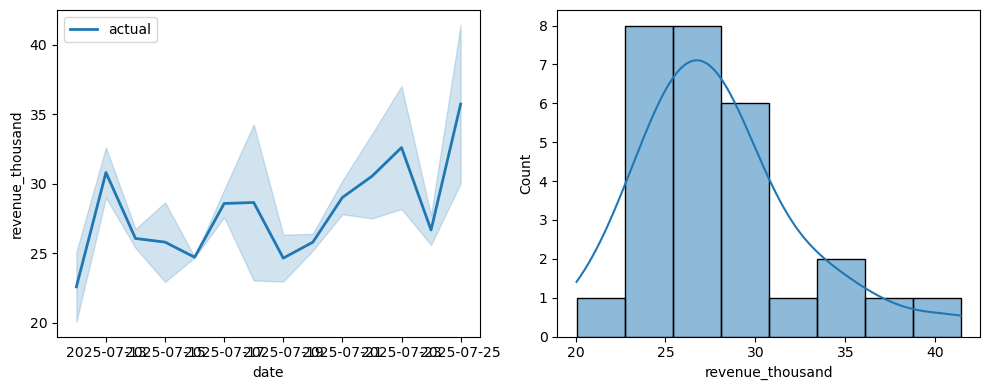

In [24]:
plt.figure(figsize=(10,4))

plt.subplot(121)  # グラフ1行2列の1番目
sns.lineplot(data=df1_daily, x='date', y='revenue_thousand', linewidth=2, label='actual')

plt.subplot(122)  # グラフ1行2列の2番目
sns.histplot(data=df1_daily, x='revenue_thousand', kde=True)

plt.tight_layout()

In [25]:
df1_daily_control = df1_daily.query('is_treatment==0').reset_index(drop=True).copy()
df1_daily_test = df1_daily.query('is_treatment==1').reset_index(drop=True).copy()

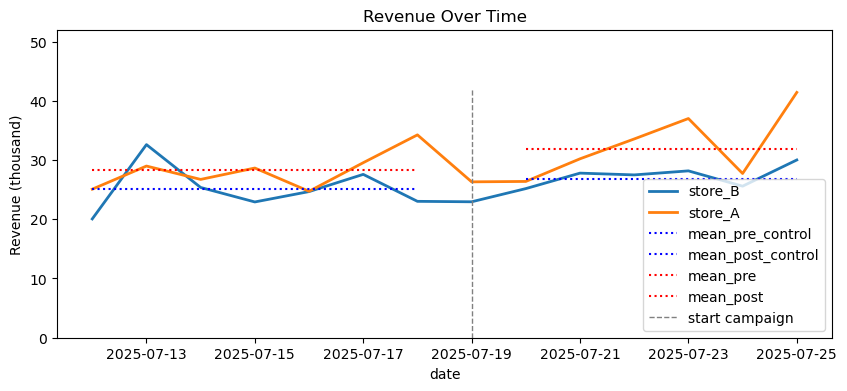

mean pre: 28.3
mean post: 31.8
diff: 3.5

mean pre control: 25.2
mean post control: 26.7
diff control: 1.6


In [26]:
# plot
plt.figure(figsize=(10,4))
sns.lineplot(data=df1_daily_control, x='date', y='revenue_thousand', linewidth=2, label='store_B')
sns.lineplot(data=df1_daily_test, x='date', y='revenue_thousand', linewidth=2, label='store_A')


# mean pre/post(control)
mean_pre_control = df1_daily_control.query('date < @base_date')['revenue_thousand'].mean()
plt.hlines(xmin=df1_daily_control['date'].min(), xmax=base_date - pd.Timedelta(days=1), y=mean_pre_control, color="blue", linestyles="dotted", linewidth=1.5, label="mean_pre_control")

mean_post_control = df1_daily_control.query('date >= @base_date')['revenue_thousand'].mean()
plt.hlines(xmin=base_date + pd.Timedelta(days=1), xmax=df1_daily_control['date'].max(), y=mean_post_control, color="blue", linestyles="dotted", linewidth=1.5, label="mean_post_control")


# mean pre/post(test)
mean_pre = df1_daily_test.query('date < @base_date')['revenue_thousand'].mean()
plt.hlines(xmin=df1_daily_test['date'].min(), xmax=base_date - pd.Timedelta(days=1), y=mean_pre, color="red", linestyles="dotted", linewidth=1.5, label="mean_pre")

mean_post = df1_daily_test.query('date >= @base_date')['revenue_thousand'].mean()
plt.hlines(xmin=base_date + pd.Timedelta(days=1), xmax=df1_daily_test['date'].max(), y=mean_post, color="red", linestyles="dotted", linewidth=1.5, label="mean_post")


# base_date
plt.vlines(x=base_date, ymin=0, ymax=max_lim, colors="gray", linestyles="dashed", linewidth=1, label="start campaign")

# plt.ylim(min_lim, max_lim)
plt.ylim(0, max_lim+10)

plt.ylabel("Revenue (thousand)")
plt.title("Revenue Over Time")
plt.legend(loc="best")
plt.show()


print(f"mean pre: {(mean_pre).round(1)}")
print(f"mean post: {(mean_post).round(1)}")
print(f"diff: {(mean_post - mean_pre).round(1)}")
print('\n', end='')  # 空白1行を挟む
print(f"mean pre control: {(mean_pre_control).round(1)}")
print(f"mean post control: {(mean_post_control).round(1)}")
print(f"diff control: {(mean_post_control - mean_pre_control).round(1)}")


# Parallel Trend Assumption check

In [27]:
# filtering data
# 必要カラムに絞り込んでdataframeをcopy
# 時点：もともとの日付型のとabsolute_ds, relative_dsの3コ
# 目的変数：revenueとか
# 個体識別子：customer_idのようなもの
# cluster, is_treatment, is_afterの3コ
df = df1[['date', 'absolute_ds', 'relative_ds', 'customer_id', 'price', 'cluster', 'is_treatment', 'is_after']].copy()
#一部のカラム名を変更、上書き
df.rename(columns={'date': 'ds', 'price': 'y', 'customer_id': 'unique_id'}, inplace=True)

In [28]:
# draft check for PTA
pd.pivot_table(df, index=['is_after', 'absolute_ds', 'relative_ds', 'ds'], columns=['cluster', 'is_treatment'], values='y', aggfunc='mean').round(1)

cluster                                       cafe       
is_treatment                                     0      1
is_after absolute_ds relative_ds ds                      
0        1           -6          2025-07-12  691.6  597.1
         2           -5          2025-07-13  665.4  674.0
         3           -4          2025-07-14  667.6  722.4
         4           -3          2025-07-15  694.6  682.1
         5           -2          2025-07-16  704.9  686.8
         6           -1          2025-07-17  656.6  687.2
         7            0          2025-07-18  657.9  634.2
1        8            1          2025-07-19  740.3  877.2
         9            2          2025-07-20  585.5  824.6
         10           3          2025-07-21  712.5  888.4
         11           4          2025-07-22  670.5  818.5
         12           5          2025-07-23  687.1  948.9
         13           6          2025-07-24  731.1  866.5
         14           7          2025-07-25  666.9  900.4

In [29]:
# draft check for DID
pd.pivot_table(df, index='is_after', columns=['cluster', 'is_treatment'], values='y', aggfunc='mean').round(1)

cluster        cafe       
is_treatment      0      1
is_after                  
0             675.2  666.5
1             680.6  876.4

In [30]:
# check sample size by is after
pd.pivot_table(df, index=['cluster', 'is_after'], columns='is_treatment', values='unique_id', aggfunc='count')

is_treatment        0    1
cluster is_after          
cafe    0         261  297
        1         275  254

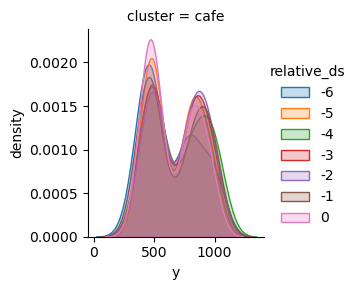

count   mean    std    min    25%    50%  \
cluster is_treatment ds                                                     
cafe    0            2025-07-12   29.0  691.6  219.0  358.0  464.0  762.0   
                     2025-07-13   49.0  665.4  207.2  382.0  473.0  711.0   
                     2025-07-14   38.0  667.6  218.6  340.0  470.2  589.5   
                     2025-07-15   33.0  694.6  219.9  382.0  508.0  599.0   
                     2025-07-16   35.0  704.9  208.8  346.0  478.0  768.0   
                     2025-07-17   42.0  656.6  227.1  325.0  440.5  628.0   
                     2025-07-18   35.0  657.9  205.1  375.0  460.0  726.0   
        1            2025-07-12   42.0  597.1  220.1  305.0  445.0  489.0   
                     2025-07-13   43.0  674.0  205.9  403.0  488.0  589.0   
                     2025-07-14   37.0  722.4  234.0  382.0  485.0  800.0   
                     2025-07-15   42.0  682.1  210.4  318.0  472.8  775.5   
                     2025-07-16   36.0  686.8  215.7  357.0  497.2  656.0   
                     2025-07-17   43.0  687.2  230.1  346.0  479.5  730.0   
                     2025-07-18   54.0  634.2  202.3  344.0  467.0  521.5   

                                   75%     max  
cluster is_treatment ds                         
cafe    0            2025-07-12  837.0  1036.0  
                     2025-07-13  831.0  1009.0  
                     2025-07-14  876.5  1058.0  
                     2025-07-15  899.0  1033.0  
                     2025-07-16  872.5  1019.0  
                     2025-07-17  847.0  1039.0  
                     2025-07-18  827.5   980.0  
        1            2025-07-12  766.5  1009.0  
                     2025-07-13  838.0  1031.0  
                     2025-07-14  920.0  1051.0  
                     2025-07-15  834.5  1037.0  
                     2025-07-16  892.2  1022.0  
                     2025-07-17  903.5  1004.0  
                     2025-07-18  814.8   987.0

In [31]:
# check distribution in before period
# 工程1.df_before作成は後で使うので必要だが、2.3はやらなくてもいい
# （たぶんもともとの意図は傾きの検定をmeanとmedianどっちでやるのがいいかの参考にしたくて分布を見てたんだと思う）

# 1. Filter the data
df_before = df.query('is_after==0')

# 2. Group by identifier, point_in_time, and cluster
grouped_df = df_before.groupby(['unique_id', 'relative_ds', 'cluster']).agg(y=('y', 'sum')).reset_index()

# 3. Create facet grid with density plots for each cluster
g = sns.FacetGrid(grouped_df, col='cluster', hue='relative_ds', col_wrap=1, height=3)
g.map(sns.kdeplot, 'y', fill=True).add_legend()
g.set_axis_labels("y", "density")
plt.show()

#上記p1otは分布をcluster，時点ごとに（is_treatment不問で）全体感見てるわけだがもっと楽をして
# density plotではなく要約統計量で見る簡易バージョン

# 3. Describe by cluster, is_treatment, point_in_time
df_before.groupby(['cluster', 'is_treatment', 'ds']).describe()['y'].round(1).sort_values(by=['cluster', 'is_treatment', 'ds'], ascending=[True, True, True])

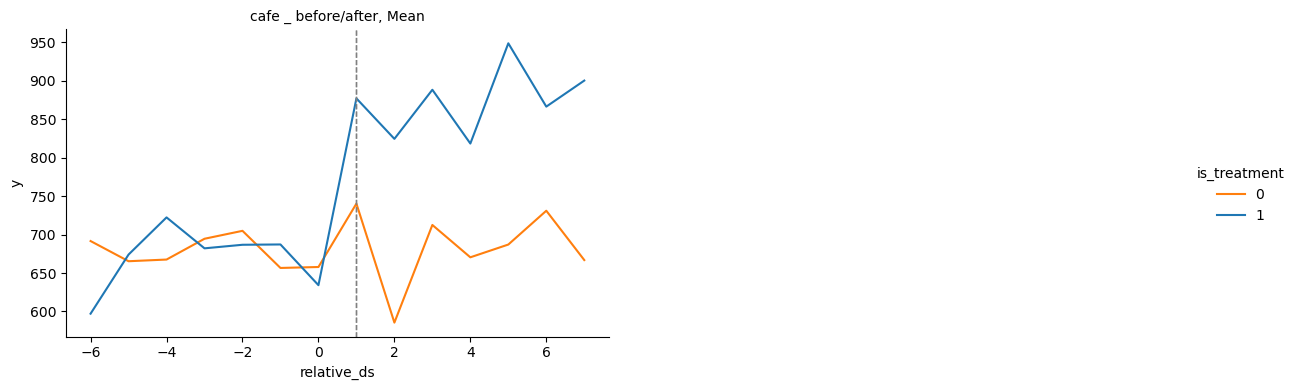

In [32]:
# 傾きの検定コーナーの前フリとして、傾きのもとになるplotをみておく
# 時点単位のplotを、平均の場合と中央値の場合で2通り
# plot (mean)
# data for plot (calculate mean for each group)
df_mean = df.groupby(['ds', 'absolute_ds', 'relative_ds', 'cluster', 'is_treatment', 'is_after'], as_index=False)['y'].mean()

# specify sort order
col_order = np.sort(df['cluster'].unique()).tolist()
hue_order = np.sort(df['is_treatment'].unique()).tolist()

# customer_color_list
custom_palette = ["tab:orange", "tab:blue"]

g = sns.FacetGrid(df_mean, col='cluster', hue='is_treatment', col_order=col_order, hue_order=hue_order,
                  palette=custom_palette,  # only mean
                  col_wrap=2, height=4, aspect=1.5
                  )
g.map(sns.lineplot, 'relative_ds', 'y')
g.add_legend ()
g.refline(x=1, color="gray", lw=1)
g.set_titles ("{col_name} _ before/after, Mean")
plt.show()

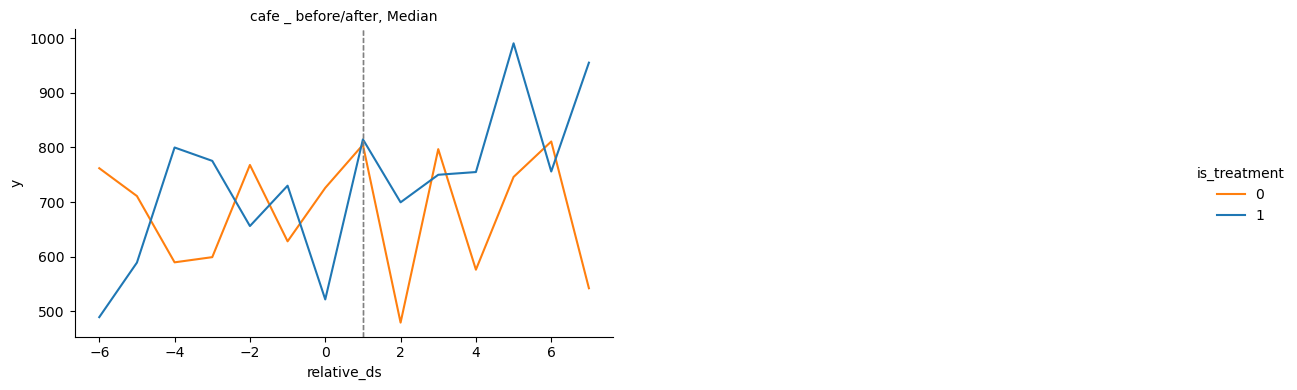

In [33]:
# 傾きの検定コーナーの前フリとして、傾きのもとになるplotをみておく
# 時点単位のplotを、平均の場合と中央値の場合で2通り
# plot (median)
# data for plot (calculate median for each group)
df_median = df.groupby(['ds', 'absolute_ds', 'relative_ds', 'cluster', 'is_treatment', 'is_after'], as_index=False)['y'].median()

# specify sort order
col_order = np.sort(df['cluster'].unique()).tolist()
hue_order = np.sort(df['is_treatment'].unique()).tolist()

# customer_color_list
custom_palette = ["tab:orange", "tab:blue"]

g = sns.FacetGrid(df_median, col='cluster', hue='is_treatment', col_order=col_order, hue_order=hue_order,
                  palette=custom_palette,  # only median
                  col_wrap=2, height=4, aspect=1.5
                  )
g.map(sns.lineplot, 'relative_ds', 'y')
g.add_legend ()
g.refline(x=1, color="gray", lw=1)
g.set_titles ("{col_name} _ before/after, Median")
plt.show()

# 傾きの検定
- 傾きの検定と書いてるが、やってることは2元配置分散分析（回帰分析）
1. PTAチェックしたい期間の、介入/統制それぞれの時点データ（meanやmedianに要約）を用意して、
1. 交互作用を組み込んだ線形回帰モデルでOLS推定する
- model: 各時点売上mean(median)= 時点数 * 介入有無
- 時点数の増減と各時点売上要約統計量の増減は連動していると位置づけたモデルにて、交互作用項の推定量に着目した回帰分析を用いてPTA判断する

- HO: 傾きは同じ（交互作用はない）
- H1: 帰無仮説は成立しない（交互作用あり）
- 交互作用なければ（介入群と統制群の時点推移が平行っぽいならば）、傾きは同程度っぽい=PTA満たされると解釈する
- 時点と介入有無の交互作用あれば（介入群と統制群の時点推移が交差する感あれば）、傾きは異なる=PTA満たされないと解釈する

In [34]:
import statsmodels.api as sm 
from statsmodels.formula. api import ols
from statsmodels.stats.anova import anova_lm

# prepare cluster group
cluster_df = pd.DataFrame(df['cluster'].drop_duplicates().sort_values()).reset_index(drop=True)
# 傾きの検定の対象期間を指定
start_ds = df_before['relative_ds'].min()
end_ds = df_before['relative_ds'].max()

# なんらか事情から特定期間に指定するもよし
# start_ds = "2024-04-16"
# end_ds = "2024-04-21"

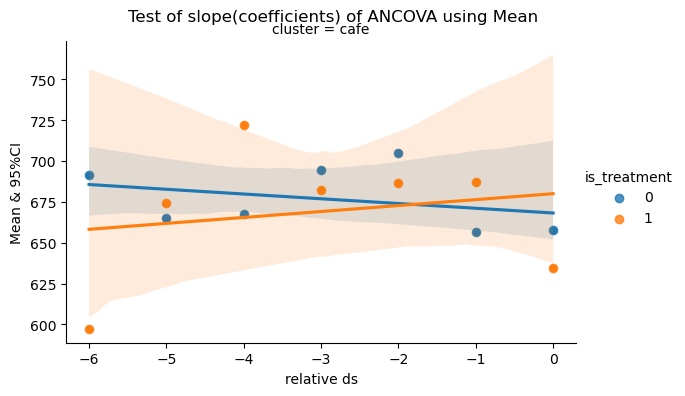

In [35]:
ancova_mean_res = pd.DataFrame ()

# ANCOVA by cluster
for i in range(len(cluster_df)) :
    cluster_id = cluster_df['cluster'].iloc[i]
    df_ancova = df_mean.query("@start_ds <= relative_ds <= @end_ds & cluster == @cluster_id").reset_index(drop=True)
    # df_ancova = df_mean.query("@start_ds <= ds <= @end_ds & cluster == @cluster_id").reset_index(drop=True)
    # test the difference of slope
    # fit1：時点とis_treatmentのみ（交互作用項含めない）モデル
    formula1 = 'y ~ relative_ds + is_treatment'
    model1 = ols(formula1, data=df_ancova).fit()
    # fit2：両者の交互作用項含めたモデル
    formula2 = 'y ~ relative_ds * is_treatment'
    model2 = ols(formula2, data=df_ancova).fit()
    #p値を抽出
    p_value = anova_lm(model1, model2).iloc[1, 5]  # null hypothesis: the slope is parallel.
    #データフレームに追加
    temp_df = pd.DataFrame({"cluster": [cluster_df["cluster"].iloc[i]], "pvalue": [p_value]})
    ancova_mean_res = pd.concat([ancova_mean_res, temp_df])

# customer_color_list
custom_palette = ["tab:blue", "tab:orange"]
# 点プロットと回帰直線の描画
g = sns.FacetGrid(df_mean.query("@start_ds <= relative_ds <= @end_ds"),
                  col='cluster', hue='is_treatment', col_order=col_order, hue_order=hue_order,
                  palette=custom_palette, col_wrap=1, height=4, aspect=1.5)
g.map(sns.scatterplot, 'relative_ds', 'y')
g.map(sns.regplot, 'relative_ds', 'y')
g.add_legend()
g.set_axis_labels("relative ds", "Mean & 95%CI")
g.figure.suptitle("Test of slope(coefficients) of ANCOVA using Mean", fontsize=12)
plt.subplots_adjust(top=0.9)
plt.show()

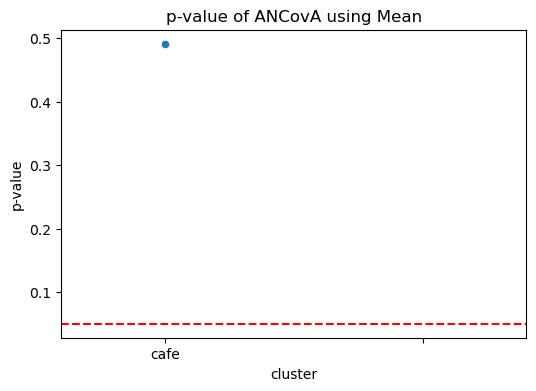

  cluster  pvalue
0    cafe   0.491
If the p-value is greater than 0.05, the null hypothesis cannot be rejected.
That is, we can assume that the parallel trend assumption is satisfied.


In [36]:
# plot all p-values using mean
plt.figure(figsize=(6, 4))
sns.scatterplot(data=ancova_mean_res, x='cluster', y='pvalue')
plt.axhline(y=0.05, linestyle='dashed', color='red')
plt.xlabel('cluster')
plt.ylabel('p-value')
plt.title('p-value of ANCovA using Mean')
plt.xticks([0, 1])
plt.xlim(-0.4, 1.4)  # spacing x scale for better visualization
plt.show()

print(ancova_mean_res.round(3))
print("If the p-value is greater than 0.05, the null hypothesis cannot be rejected.")
print("That is, we can assume that the parallel trend assumption is satisfied.")
# 交互作用項のp値をクラスタごとに横並びに表示
# 赤線p=0.05よりも下にplotされたクラスタは、PTA満たされないとの解釈成り立つ

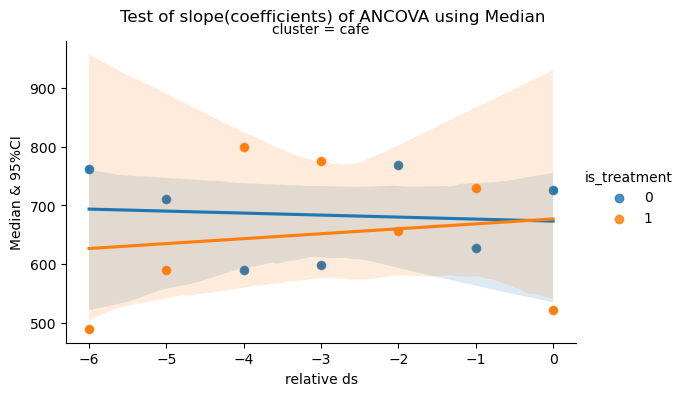

In [37]:
# 傾きの検定コーナー（medianバージョン）
# 上と同じことを「中央値」でやる
ancova_median_res = pd.DataFrame ()

# ANCOVA by cluster
for i in range(len(cluster_df)) :
    cluster_id = cluster_df['cluster'].iloc[i]
    df_ancova = df_median.query("@start_ds <= relative_ds <= @end_ds & cluster == @cluster_id").reset_index(drop=True)
    # df_ancova = df_mean.query("@start_ds <= ds <= @end_ds & cluster == @cluster_id").reset_index(drop=True)
    # test the difference of slope
    # fit1：時点とis_treatmentのみ（交互作用項含めない）モデル
    formula1 = 'y ~ relative_ds + is_treatment'
    model1 = ols(formula1, data=df_ancova).fit()
    # fit2：両者の交互作用項含めたモデル
    formula2 = 'y ~ relative_ds * is_treatment'
    model2 = ols(formula2, data=df_ancova).fit()
    #p値を抽出
    p_value = anova_lm(model1, model2).iloc[1, 5]  # null hypothesis: the slope is parallel.
    #データフレームに追加
    temp_df = pd.DataFrame({"cluster": [cluster_df["cluster"].iloc[i]], "pvalue": [p_value]})
    ancova_median_res = pd.concat([ancova_median_res, temp_df])

# customer_color_list
custom_palette = ["tab:blue", "tab:orange"]
# 点プロットと回帰直線の描画
g = sns.FacetGrid(df_median.query("@start_ds <= relative_ds <= @end_ds"),
                  col='cluster', hue='is_treatment', col_order=col_order, hue_order=hue_order,
                  palette=custom_palette, col_wrap=1, height=4, aspect=1.5)
g.map(sns.scatterplot, 'relative_ds', 'y')
g.map(sns.regplot, 'relative_ds', 'y')
g.add_legend()
g.set_axis_labels("relative ds", "Median & 95%CI")
g.figure.suptitle("Test of slope(coefficients) of ANCOVA using Median", fontsize=12)
plt.subplots_adjust(top=0.9)
plt.show()

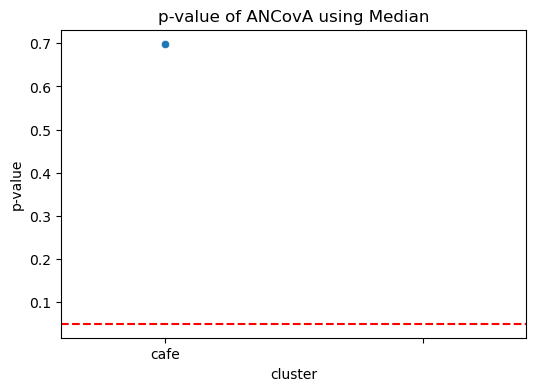

  cluster  pvalue
0    cafe   0.699
If the p-value is greater than 0.05, the null hypothesis cannot be rejected.
That is, we can assume that the parallel trend assumption is satisfied.


In [38]:
# plot all p-values using median
plt.figure(figsize=(6, 4))
sns.scatterplot(data=ancova_median_res, x='cluster', y='pvalue')
plt.axhline(y=0.05, linestyle='dashed', color='red')
plt.xlabel('cluster')
plt.ylabel('p-value')
plt.title('p-value of ANCovA using Median')
plt.xticks([0, 1])
plt.xlim(-0.4, 1.4)  # spacing x scale for better visualization
plt.show()

print(ancova_median_res.round(3))
print("If the p-value is greater than 0.05, the null hypothesis cannot be rejected.")
print("That is, we can assume that the parallel trend assumption is satisfied.")
# 交互作用項のp値をクラスタごとに横並びに表示
# 赤線p=0.05よりも下にplotされたクラスタは、PTA満たされないとの解釈成り立つ

# ベンチマーク方式
- ベンチマーク方式と書いてるが、やってることはDID R packageを模したpseudo-ATT（基準時点定しての回帰分析）
1. 傾き方式では、期間内の時点をひとかたまりの量的変数で捉えていた（1クラスターにつき回帰モデルは1コだけ）
1. ベンチマーク方式では、期間内の時点を別々（の質的変数）として扱う
1. 介入直前の時点を基準点とし、基準点とその1時点前とで回帰モデル、基準点とその2時点前とで回帰モデル、、、とモデルを複数作成する
1. モデルの基本的枠組みは傾き方式と同じ。交互作用を組み込んだ線形回帰モデルでOLS推定する

- model：ある時点の売上＝基準点/not＊介入有無
- 基準点/notと介入有無の掛け合わせ次第で時点売上は変動すると位置づけたモデルにて、交互作用項の推定量に着用した回帰分析を用いてPTA判断する
- （ATT: Average Treatment Effect on the Treated 介入群における平均処置効果が2時点で同程度かを見ている、なのでスードATT 疑似ATT とも呼んでる）

- HO: 2時点のATTは同程度である（交互作用はない）
- H1: 帰無仮説は成立しない（交互作用あり）
- 2時点のATTは同程度っぽいならば、当該2時点における2群の関係性は平行っぽい
- 2時点のATTは同程度っぽくなければ、該2時点における2群の関係性は平行と言い難い
- 時点の数ぶんモデルを作成し、各モデルの交互作用項の頼区間を取り出して、どの2時点においても頼区間が0をまたいでいれば（どの2時点においてもATTは同程度っぽいならば）、PTA満たされると解釈する
- いずれかの2時点において信頼区間が0をまたいでいなければ（いずれかの2時点にてATTは同程度っぽくなければ）、PTA満たされないと解釈する

In [39]:
# 時点と相対時点の対応表を作成
df_rel_point = df[['ds', 'relative_ds']].drop_duplicates().sort_values(by=['ds', 'relative_ds']).reset_index(drop=True)
df_rel_point

,ds,relative_ds
0,2025-07-12,-6
1,2025-07-13,-5
2,2025-07-14,-4
3,2025-07-15,-3
4,2025-07-16,-2
5,2025-07-17,-1
6,2025-07-18,0
7,2025-07-19,1
8,2025-07-20,2
9,2025-07-21,3


In [40]:
# pseudo-ATTの対象期間を指定
start_ds = df['relative_ds'].min()
end_ds = df['relative_ds'].max()
benchmark_ds = df_before['relative_ds'].max()

# なんらか事情から特定期間に指定するもよし
# start_ds = "2024-04-16"
# end ds = "2024-04-21"
# benchmark ds = "2024-04-21"

In [41]:
# looping
# benchmark（介入直前の基準とする）時点と、PTA checkしたい時点を取り出して、
# 前者は0 後者は1としたbenchmarkカラムを追加して、
# benchmarkとis_treatmentの交互作用含めた回帰をおこない
# 交互作用項の推定量と信頼区間を取り出す
# 以上をclusterごとにそして時点ごとに繰り返している
import statsmodels.formula.api as smf
patt_all_res = pd.DataFrame()
for i in range(len(cluster_df)):
    cluster_id = cluster_df["cluster"].iloc[i]
    df_patt = df.query('@start_ds <= relative_ds <= @end_ds & cluster == @cluster_id').reset_index(drop=True)
for j in range(len(df_rel_point)) :
    time_ = df_rel_point.loc[j, 'ds']
    point_ = df_rel_point.loc[j,'relative_ds']
    df_filtered = df_patt[(df_patt['relative_ds'] == benchmark_ds) | (df_patt['relative_ds'] == point_)].reset_index(drop=True)
    df_filtered['benchmark'] = df_filtered.apply(lambda row: 0 if row['relative_ds'] == benchmark_ds else 1, axis=1)

    # model = smf.ols(formula='y ~ benchmark + is_treatment + benchmark:is_treatment', data=df_filtered).fit()  # for non robust se
    # model = smf.ols(formula='y ~ benchmark + is_treatment + benchmark:is_treatment', data=df_filtered).fit (cov_type='HC3', use_t=True)  
    # # for robust se
    # coef_ = model.params["benchmark:is_treatment" ]
    # conf_lower95 = model.t_test(["benchmark:is_treatment"]).conf_int(alpha=0.05) [0,0]
    # conf_upper95 = model.t_test(["benchmark:is_treatment" ]).conf_int(alpha=0.05) [0,1]

    model = smf.ols (formula='y ~ benchmark + is_treatment + benchmark:is_treatment', data=df_filtered).fit()
    # for cluster-robust se
    model_robust = model.get_robustcov_results(cov_type='cluster', groups=df_filtered['unique_id'])
    coef_ = model_robust.params[3]
    conf_lower95 = model_robust.t_test(["benchmark:is_treatment"]).conf_int(alpha=0.05)[0,0]
    conf_upper95 = model_robust.t_test(["benchmark:is_treatment"]).conf_int(alpha=0.05)[0,1]

    patt_res = pd.DataFrame({'cluster': cluster_df['cluster'][i],
                              'ds': time_,
                              'relative_ds': point_,
                              'coef': coef_,
                              'conf_lower95': conf_lower95,
                              'conf_upper95': conf_upper95
                              }, index=[0])
    patt_all_res = pd.concat([patt_all_res, patt_res], ignore_index=True)

In [42]:
# result
patt_all_res['is_after'] = patt_all_res['relative_ds'].apply(lambda x: 1 if x > 0 else 0)
patt_all_res.round(3)

,cluster,ds,relative_ds,coef,conf_lower95,conf_upper95,is_after
0,cafe,2025-07-12,-6,-70.843,-205.472,63.786,0
1,cafe,2025-07-13,-5,32.314,-89.097,153.725,0
2,cafe,2025-07-14,-4,78.461,-53.534,210.455,0
3,cafe,2025-07-15,-3,11.172,-126.817,149.160,0
4,cafe,2025-07-16,-2,5.498,-125.456,136.453,0
5,cafe,2025-07-17,-1,54.202,-70.462,178.866,0
6,cafe,2025-07-18,0,0.000,0.000,0.000,0
7,cafe,2025-07-19,1,160.512,11.563,309.462,1
8,cafe,2025-07-20,2,262.686,128.556,396.816,1
9,cafe,2025-07-21,3,199.538,60.260,338.815,1


In [43]:
# benchmarkよりも前の時点で、信頼区間が0をまたいでないレコードのみを表示する
patt_all_res.query('(0 < conf_lower95 | conf_upper95 < 0) & (is_after == 0)').round(3)
# ここで表示されるレコードがあるようだと、該当クラスターはPTA満たしてないとの解釈になる

,cluster,ds,relative_ds,coef,conf_lower95,conf_upper95,is_after


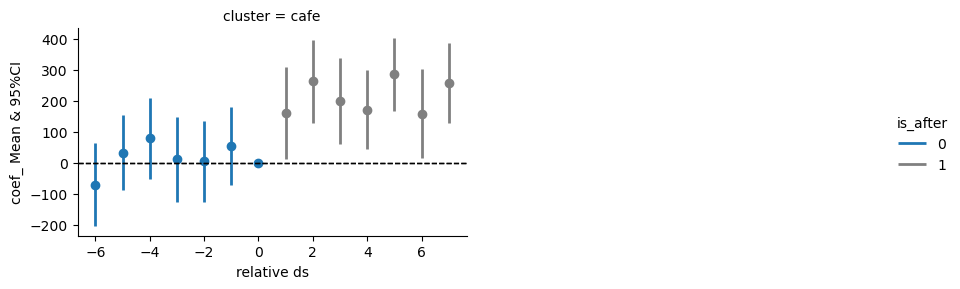

In [44]:
# 上記結果をグラフ描画
# benchmark（基準時点）よりも前の時点で、信頼区間の上下限（縦棒）が（横破線）をまたいでいれば、PTA満たしてるとの解釈
# customer_color_list
custom_palette = ["tab:blue", "gray"]

# plot
g = sns.FacetGrid(patt_all_res, col='cluster', hue='is_after', col_order=col_order, hue_order=[0, 1], palette=custom_palette, col_wrap=2, height=3, aspect=1.5)
g.map(plt.scatter, 'relative_ds', 'coef')
g.map(plt.vlines, 'relative_ds', 'conf_lower95', 'conf_upper95', label='95% CI', linewidth=2)
g.add_legend ()
g.refline(y=0, color = "black", lw=1)
g.set_axis_labels("relative ds", "coef_ Mean & 95%CI")
plt.show()

# DID
- before/afterの2時点ではなく、複数時点別でのDIDをOLSで
- Pythonで学ぶ効果検証入門でやってたやつ

In [45]:
df.head()

,ds,absolute_ds,relative_ds,unique_id,y,cluster,is_treatment,is_after
0,2025-07-12,1,-6,2ohuswkk,1000,cafe,1,0
1,2025-07-13,2,-5,2ohuswkk,462,cafe,1,0
2,2025-07-14,3,-4,2ohuswkk,814,cafe,1,0
3,2025-07-15,4,-3,2ohuswkk,404,cafe,1,0
4,2025-07-16,5,-2,2ohuswkk,768,cafe,1,0


In [46]:
# 土日祝日フラグを追加する

# 1. 祝日データの作成
import jpholiday

# df['ds'] から期間の開始日と終了日を取得
start = df['ds'].min()
end = df['ds'].max()
# または手打ち
# start = pd.to_datetime("2025-07-01")
# end = pd.to_datetime("2025-07-31")

# 年をまたぐ可能性考えて、ユニークな年を取得
years = df['ds'].dt.year.unique()

holidays_list = []
for y in years:
    for date, name in jpholiday.year_holidays(int(y)):
        # データの期間内に入っている祝日だけ追加
        if start.date() <= date <= end.date():
            holidays_list.append({'ds': pd.to_datetime(date), 'holiday': name})

holidays_df = pd.DataFrame(holidays_list)
holidays_df

,ds,holiday
0,2025-07-21,海の日


In [47]:
# 2. 土日フラグを立てておいて（5:土曜日, 6:日曜日）
df["is_holiday"] = df["ds"].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# 3. holidays_df に含まれる日付（平日祝日）を 1 に更新する
# dt.normalize() を使うと時刻が 00:00:00 に揃うので比較が確実
holiday_dates = holidays_df['ds'].dt.normalize()
df.loc[df['ds'].dt.normalize().isin(holiday_dates), "is_holiday"] = 1

In [48]:
# 数値を文字列に変換し、1桁の場合はゼロで埋める
df['absolute_ds_str'] = df['absolute_ds'].astype(str).str.zfill(2)
# 時点に関するダミー変数を作成
abs_ds_dummies = pd.get_dummies(df["absolute_ds_str"], prefix="abs_ds", drop_first=False, dtype=int)
df_reg = pd.concat([df, abs_ds_dummies], axis=1)

In [49]:
df_reg.head()

,ds,absolute_ds,relative_ds,unique_id,y,cluster,is_treatment,is_after,is_holiday,absolute_ds_str,...,abs_ds_05,abs_ds_06,abs_ds_07,abs_ds_08,abs_ds_09,abs_ds_10,abs_ds_11,abs_ds_12,abs_ds_13,abs_ds_14
0,2025-07-12,1,-6,2ohuswkk,1000,cafe,1,0,1,01,...,0,0,0,0,0,0,0,0,0,0
1,2025-07-13,2,-5,2ohuswkk,462,cafe,1,0,1,02,...,0,0,0,0,0,0,0,0,0,0
2,2025-07-14,3,-4,2ohuswkk,814,cafe,1,0,0,03,...,0,0,0,0,0,0,0,0,0,0
3,2025-07-15,4,-3,2ohuswkk,404,cafe,1,0,0,04,...,0,0,0,0,0,0,0,0,0,0
4,2025-07-16,5,-2,2ohuswkk,768,cafe,1,0,0,05,...,1,0,0,0,0,0,0,0,0,0


In [50]:
# 分析
formula = (
    "y ~ is_treatment + is_after + is_holiday"
    " + abs_ds_01: is_treatment" 
    " + abs_ds_02: is_treatment"
    " + abs_ds_03: is_treatment"
    " + abs_ds_04: is_treatment"
    " + abs_ds_05: is_treatment"
    " + abs_ds_06: is_treatment"
    " + abs_ds_08: is_treatment"
    " + abs_ds_09: is_treatment"
    " + abs_ds_10: is_treatment"
    " + abs_ds_11: is_treatment"
    " + abs_ds_12: is_treatment"
    " + abs_ds_13: is_treatment"
    " + abs_ds_14: is_treatment"
)
result = smf.ols(formula=formula, data=df_reg).fit()
# result.summary()

# クラスター unique_id指定してクラスター頑健標準誤差で補正
result_clustered = result.get_robustcov_results(cov_type="cluster", groups=df_reg['unique_id'])
result_clustered.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     10.45
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           4.96e-19
Time:                        10:47:03   Log-Likelihood:                -7377.2
No. Observations:                1087   AIC:                         1.479e+04
Df Residuals:                    1070   BIC:                         1.487e+04
Df Model:                          16                                         
Covariance Type:              cluster                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                677.6507     15.560     43.551      0.000     646.967     708.334
is_treatment             -43.4284     31.633     -1.373      0.171    -105.807      18.950
is_after                   6.3612     18.705      0.340      0.734     -30.524      43.246
is_holiday                -8.2413     20.060     -0.411      0.682     -47.800      31.317
abs_ds_01:is_treatment   -28.8380     45.505     -0.634      0.527    -118.571      60.895
abs_ds_02:is_treatment    48.0656     46.754      1.028      0.305     -44.131     140.262
abs_ds_03:is_treatment    88.1562     48.621      1.813      0.071      -7.722     184.034
abs_ds_04:is_treatment    47.9206     44.286      1.082      0.281     -39.409     135.251
abs_ds_05:is_treatment    52.5556     45.295      1.160      0.247     -36.765     141.876
abs_ds_06:is_treatment    52.9638     41.315      1.282      0.201     -28.507     134.435
abs_ds_08:is_treatment   244.8579     57.016      4.295      0.000     132.425     357.290
abs_ds_09:is_treatment   192.2204     57.241      3.358      0.001      79.343     305.098
abs_ds_10:is_treatment   256.0991     57.272      4.472      0.000     143.161     369.037
abs_ds_11:is_treatment   177.8800     45.728      3.890      0.000      87.707     268.053
abs_ds_12:is_treatment   308.2883     44.438      6.938      0.000     220.659     395.918
abs_ds_13:is_treatment   225.9165     55.877      4.043      0.000     115.730     336.103
abs_ds_14:is_treatment   259.7861     47.442      5.476      0.000     166.233     353.339
==============================================================================
Omnibus:                     7718.954   Durbin-Watson:                   1.922
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              105.573
Skew:                           0.144   Prob(JB):                     1.19e-23
Kurtosis:                       1.501   Cond. No.                         25.0
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [51]:
# result.summary().tables[1]
result_clustered.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,677.6507,15.560,43.551,0.000,646.967,708.334
is_treatment,-43.4284,31.633,-1.373,0.171,-105.807,18.950
is_after,6.3612,18.705,0.340,0.734,-30.524,43.246
is_holiday,-8.2413,20.060,-0.411,0.682,-47.800,31.317
abs_ds_01:is_treatment,-28.8380,45.505,-0.634,0.527,-118.571,60.895
abs_ds_02:is_treatment,48.0656,46.754,1.028,0.305,-44.131,140.262
abs_ds_03:is_treatment,88.1562,48.621,1.813,0.071,-7.722,184.034
abs_ds_04:is_treatment,47.9206,44.286,1.082,0.281,-39.409,135.251
abs_ds_05:is_treatment,52.5556,45.295,1.160,0.247,-36.765,141.876
abs_ds_06:is_treatment,52.9638,41.315,1.282,0.201,-28.507,134.435


In [ ]:
# SimpleTable (statsmodels独自型)ではなく、pd.DataFrameでの出力のほうを格納
# df_ols_result = result.summary2().tables[1].copy()
df_ols_result = result_clustered.summary2().tables[1].copy()

In [53]:
df_ols_result

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,677.650670,15.560018,43.550765,1.090632e-103,646.966991,708.334348
is_treatment,-43.428448,31.632892,-1.372889,1.713320e-01,-105.807136,18.950241
is_after,6.361228,18.704803,0.340085,7.341510e-01,-30.523831,43.246287
is_holiday,-8.241344,20.060490,-0.410825,6.816431e-01,-47.799759,31.317071
abs_ds_01:is_treatment,-28.838021,45.504550,-0.633739,5.269787e-01,-118.571017,60.894975
abs_ds_02:is_treatment,48.065633,46.753970,1.028055,3.051721e-01,-44.131164,140.262431
abs_ds_03:is_treatment,88.156156,48.620653,1.813142,7.131660e-02,-7.721659,184.033972
abs_ds_04:is_treatment,47.920635,44.286021,1.082071,2.805303e-01,-39.409475,135.250745
abs_ds_05:is_treatment,52.555556,45.295422,1.160284,2.473233e-01,-36.765048,141.876160
abs_ds_06:is_treatment,52.963824,41.314820,1.281957,2.013492e-01,-28.507205,134.434853


In [54]:
# 交互作用項のところだけをグラフ描画したいので、そのための前処理
# 不要な行をdrop
df_ols_result.drop(['Intercept', 'is_treatment', 'is_after', 'is_holiday'], axis=0, inplace=True)
# 不要な列をdrop
df_ols_result.drop(['Std.Err.', 't', 'P>|t|'], axis=1, inplace=True)
# 全部のカラム名（列名）を変更、かつ元dfを上書き
df_ols_result = df_ols_result.set_axis(['mean', 'lower', 'upper' ], axis=1, copy=False)
# インデックスから不要部分を除外
df_ols_result.index = df_ols_result.index.str.replace(':is_treatment', '')
# 新しいレコードを追加し、インデックス名を指定
new_record = {'mean': 0, 'lower': 0, 'upper': 0}
df_ols_result.loc['abs_ds_07'] = new_record
# インデックスをソートして、元のDataFrameを上書き
df_ols_result.sort_index(inplace=True)

In [55]:
df_ols_result

,mean,lower,upper
abs_ds_01,-28.838021,-118.571017,60.894975
abs_ds_02,48.065633,-44.131164,140.262431
abs_ds_03,88.156156,-7.721659,184.033972
abs_ds_04,47.920635,-39.409475,135.250745
abs_ds_05,52.555556,-36.765048,141.876160
abs_ds_06,52.963824,-28.507205,134.434853
abs_ds_07,0.000000,0.000000,0.000000
abs_ds_08,244.857894,132.425438,357.290349
abs_ds_09,192.220394,79.342932,305.097855
abs_ds_10,256.099070,143.161152,369.036989


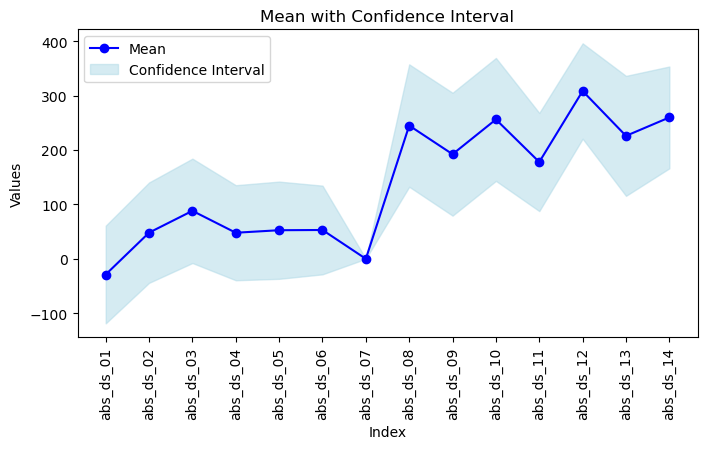

In [56]:
plt. figure(figsize=(8, 4))
plt.plot(df_ols_result.index, df_ols_result['mean'], label='Mean', color='blue', marker='o')
plt.fill_between(df_ols_result.index, df_ols_result['lower'], df_ols_result['upper'], color='lightblue', alpha=0.5, label='Confidence Interval')
plt.title('Mean with Confidence Interval')
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=90)
plt.legend ()
plt.show()